# limpieza de datos

In [112]:
import importlib
import subprocess
import sys

# Mapeo de imports → nombres reales de paquetes en pip
required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "seaborn": "seaborn",
    "statsmodels": "statsmodels",
    "sklearn": "scikit-learn",   # <- CORRECCIÓN
    "plotly": "plotly",
    "stargazer": "stargazer",
}

def safe_pip_install(package):
    """Instala un paquete si no está, sin actualizar."""
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", package],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )
        print(f"✓ {package} instalado correctamente.")
    except Exception:
        print(f"⚠ No se pudo instalar {package}. Puede estar bloqueado por Anaconda.")

def install_if_missing(import_name, pip_name):
    try:
        importlib.import_module(import_name)
        print(f"✔ {import_name} ya está instalado.")
    except ImportError:
        print(f"✖ {import_name} no está instalado. Instalando {pip_name}...")
        safe_pip_install(pip_name)

print("📦 Verificando librerías necesarias...\n")

for import_name, pip_name in required_packages.items():
    install_if_missing(import_name, pip_name)

print("\n🎉 Todas las librerías están listas.")


📦 Verificando librerías necesarias...

✔ numpy ya está instalado.
✔ pandas ya está instalado.
✔ matplotlib ya está instalado.
✔ scipy ya está instalado.
✔ seaborn ya está instalado.
✔ statsmodels ya está instalado.
✔ sklearn ya está instalado.
✔ plotly ya está instalado.
✔ stargazer ya está instalado.

🎉 Todas las librerías están listas.


In [113]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import scipy.stats as st
from scipy.stats import pointbiserialr
import seaborn as sns
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
from scipy import stats
from IPython.core.display import display, HTML
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from IPython.display import clear_output, display


C:\Users\alexf\AppData\Local\Temp\ipykernel_20660\2353184376.py:14: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [114]:
PALETTE_NAME = "Accent"
HIST_GRAY = "0.38"  # histogr. en escala de grises (sin color de relleno)

sns.set_theme(style="whitegrid")
sns.set_palette(PALETTE_NAME)

plt.rc("font", size=12)
plt.rc("axes", titlesize=16, titleweight="bold")


def palette_n(n):
    # Colores discretos derivados de la paleta principal.
    n = max(int(n), 1)
    return sns.color_palette(PALETTE_NAME, n_colors=n)

In [115]:
df=pd.read_csv("data__movies.csv")



In [116]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4775 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   original_language     4803 non-null   object 
 5   original_title        4803 non-null   object 
 6   overview              4800 non-null   object 
 7   popularity            4803 non-null   float64
 8   production_companies  4452 non-null   object 
 9   release_date          4802 non-null   object 
 10  revenue               4803 non-null   int64  
 11  runtime               4801 non-null   float64
 12  status                4803 non-null   object 
 13  tagline               3959 non-null   object 
 14  title                 4803 non-null   object 
 15  vote_average         

## contar outlier por columna

In [117]:
#contar outliers
def count_outliers(df):
    outlier_counts = {}
    for col in df.columns:

        if pd.api.types.is_numeric_dtype(df[col]):  # Solo columnas numéricas
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
            outlier_counts[col] = outliers
    outlier_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier Count'])
    outlier_df = outlier_df.sort_values(by='Outlier Count', ascending=False)        
    return outlier_df
# Contar outliers en el DataFrame df
outlier_counts = count_outliers(df)
outlier_counts.head(20)

,Outlier Count
id,704
vote_count,504
revenue,472
budget,321
popularity,275
runtime,182
vote_average,156


In [118]:
columnas = ["budget", "genres", "original_language", "popularity", "production_companies", "release_date", "revenue", "runtime", "vote_average", "vote_count"]

In [119]:
df1 = df[columnas]
df1["genres"].isna().sum()



28

In [120]:
#Dropeamos columnas NA en genres

df1 = df1.dropna(subset=['genres'])

## clasificacion por lenguanje

*Hago one-hot en 'original language', 1 - Inglés, 0 - E.O.C*

In [121]:
df1["original_language"].value_counts()

original_language
en    4477
fr      70
es      32
zh      27
de      27
hi      19
ja      16
it      14
cn      12
ru      11
ko      11
pt       9
da       7
sv       5
nl       4
fa       4
th       3
he       3
ta       2
cs       2
ro       2
id       2
ar       2
vi       1
sl       1
ps       1
no       1
ky       1
hu       1
pl       1
af       1
nb       1
tr       1
is       1
xx       1
te       1
el       1
Name: count, dtype: int64

In [122]:
df1["main_language_english"] = df1["original_language"].apply(lambda x: "1" if x == "en" else "0")


## Estudiamos el efecto del estudio que produce las películas

In [123]:
df1["production_companies"].value_counts().head(30)

production_companies
Paramount Pictures                                                 58
Universal Pictures                                                 45
New Line Cinema                                                    38
Columbia Pictures                                                  37
Metro-Goldwyn-Mayer (MGM)                                          32
Twentieth Century Fox Film Corporation                             31
Walt Disney Pictures                                               27
Warner Bros.                                                       27
Touchstone Pictures                                                26
Dimension Films                                                    17
Miramax Films                                                      16
Columbia Pictures Corporation                                      16
United Artists                                                     12
DreamWorks Animation                                               12

**Observamos que existe una gran disparidad en la cantidad de películas realizadas por cada estudio, haremos un one-hot encoding que discriminará si el estudio ha hecho más de 20 películas o no**

In [124]:

studio_long = (
    df1[['production_companies']]
    .dropna()
    .assign(production_companies=lambda d: d['production_companies'].str.split(',\s*'))
    .explode('production_companies')
)

studio_long['production_companies'] = studio_long['production_companies'].str.strip()
studio_long = studio_long[studio_long['production_companies'] != '']

studio_counts = (
    studio_long['production_companies']
    .value_counts()
    .rename_axis('studio')
    .reset_index(name='total_movies')
)

studio_counts.head(30)

,studio,total_movies
0,Warner Bros.,319
1,Universal Pictures,311
2,Paramount Pictures,285
3,Twentieth Century Fox Film Corporation,222
4,Columbia Pictures,201
5,New Line Cinema,165
6,Metro-Goldwyn-Mayer (MGM),122
7,Touchstone Pictures,118
8,Walt Disney Pictures,114
9,Relativity Media,102


## clasificacion por estudio famoso
Consideramos estudio famoso si cumple con 'total movies' > 90

In [125]:
studios_over_90 = set(studio_counts.loc[studio_counts['total_movies'] > 90, 'studio'])

def has_big_studio(companies):
    if pd.isna(companies):
        return 0
    studios = [s.strip() for s in str(companies).split(',') if s.strip()]
    return int(any(studio in studios_over_90 for studio in studios))

df1['big_studio'] = df1['production_companies'].apply(has_big_studio)
df1[['production_companies', 'big_studio']].head(10)

,production_companies,big_studio
0,"Ingenious Film Partners, Twentieth Century Fox...",1
1,"Walt Disney Pictures, Jerry Bruckheimer Films,...",1
2,"Columbia Pictures, Danjaq, B24",1
3,"Legendary Pictures, Warner Bros., DC Entertain...",1
4,Walt Disney Pictures,1
5,"Columbia Pictures, Laura Ziskin Productions, M...",1
6,"Walt Disney Pictures, Walt Disney Animation St...",1
7,"Marvel Studios, Prime Focus, Revolution Sun St...",0
8,"Warner Bros., Heyday Films",1
9,"DC Comics, Atlas Entertainment, Warner Bros., ...",1


In [126]:
df1["big_studio"].value_counts()

big_studio
0    2787
1    1988
Name: count, dtype: int64

**Limpieza de outliers en revenue**
Limpiamos 0's, y el último cuantil

In [127]:
zero_revenue_count = (pd.to_numeric(df1['revenue'], errors='coerce') == 0).sum()
total_rows = len(df1)
print(f'Rows with revenue = 0: {zero_revenue_count}')
print(f'Percentage: {zero_revenue_count/total_rows:.2%}')

Rows with revenue = 0: 1400
Percentage: 29.32%


In [128]:
df1.drop(df1[pd.to_numeric(df1['revenue'], errors='coerce') == 0].index, inplace=True)

Revenue summary:
count    3.375000e+03
mean     1.170655e+08
std      1.834995e+08
min      5.000000e+00
25%      1.536924e+07
50%      5.180119e+07
75%      1.401684e+08
90%      3.028029e+08
95%      4.622882e+08
99%      9.021396e+08
max      2.787965e+09
Name: revenue, dtype: float64

IQR bounds: {'lower': -171829511.0, 'upper': 327367145.0}
IQR outliers: 299
Z-score outliers (|z|>3): 86

Top 15 highest Revenue:
        revenue
0    2787965087
25   1845034188
16   1519557910
28   1513528810
44   1506249360
7    1405403694
124  1274219009
31   1215439994
546  1156730962
26   1153304495
52   1123746996
329  1118888979
29   1108561013
36   1091405097
3    1084939099


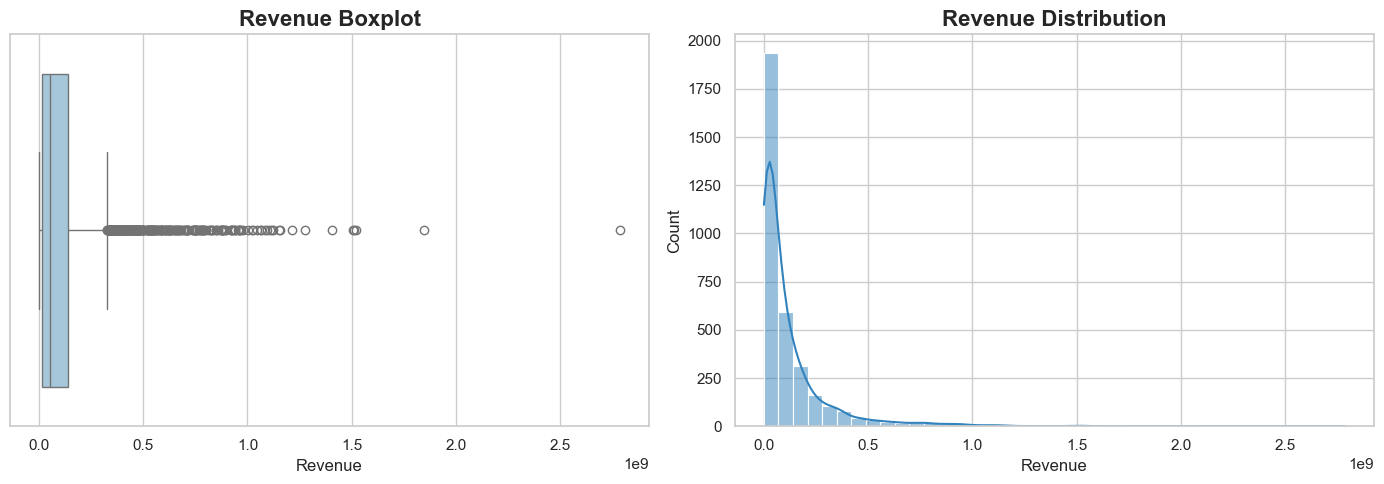

In [129]:
# Clean Revenue as numeric
revenue_clean = pd.to_numeric(df1['revenue'], errors='coerce')

# IQR method
q1 = revenue_clean.quantile(0.25)
q3 = revenue_clean.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_iqr = (revenue_clean < lower) | (revenue_clean > upper)

# Z-score method (on non-null values)
mu = revenue_clean.mean()
sigma = revenue_clean.std()
z_scores = (revenue_clean - mu) / sigma
outlier_z = z_scores.abs() > 3

print('Revenue summary:')
print(revenue_clean.describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))
print('\nIQR bounds:', {'lower': round(lower, 2), 'upper': round(upper, 2)})
print('IQR outliers:', int(outlier_iqr.sum()))
print('Z-score outliers (|z|>3):', int(outlier_z.sum()))

# Show top high-Revenue potential outliers
title_col = next((c for c in ['title', 'original_title', 'movie_title', 'name'] if c in df1.columns), None)
cols_to_show = ['revenue'] + ([title_col] if title_col else [])
print('\nTop 15 highest Revenue:')
print(df1.loc[revenue_clean.nlargest(15).index, cols_to_show])

# Visual review
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=revenue_clean, ax=axes[0], color='#9ecae1')
axes[0].set_title('Revenue Boxplot')
axes[0].set_xlabel('Revenue')

sns.histplot(revenue_clean.dropna(), bins=40, kde=True, ax=axes[1], color='#3182bd')
axes[1].set_title('Revenue Distribution')
axes[1].set_xlabel('Revenue')

plt.tight_layout()
plt.show()

Revenue summary:
count    3.375000e+03
mean     1.170655e+08
std      1.834995e+08
min      5.000000e+00
25%      1.536924e+07
50%      5.180119e+07
75%      1.401684e+08
90%      3.028029e+08
95%      4.622882e+08
99%      9.021396e+08
max      2.787965e+09
Name: revenue, dtype: float64

--- Outlier Detection ---
Percentile 99 (Top 1%): > 902139643.72
Registros excluidos (Top 1%): 34
IQR bounds: [-171829511.0, 327367145.0]
IQR outliers: 299
Z-score outliers (|z|>3): 86

Top 15 highest Revenue:
        revenue
0    2787965087
25   1845034188
16   1519557910
28   1513528810
44   1506249360
7    1405403694
124  1274219009
31   1215439994
546  1156730962
26   1153304495
52   1123746996
329  1118888979
29   1108561013
36   1091405097
3    1084939099


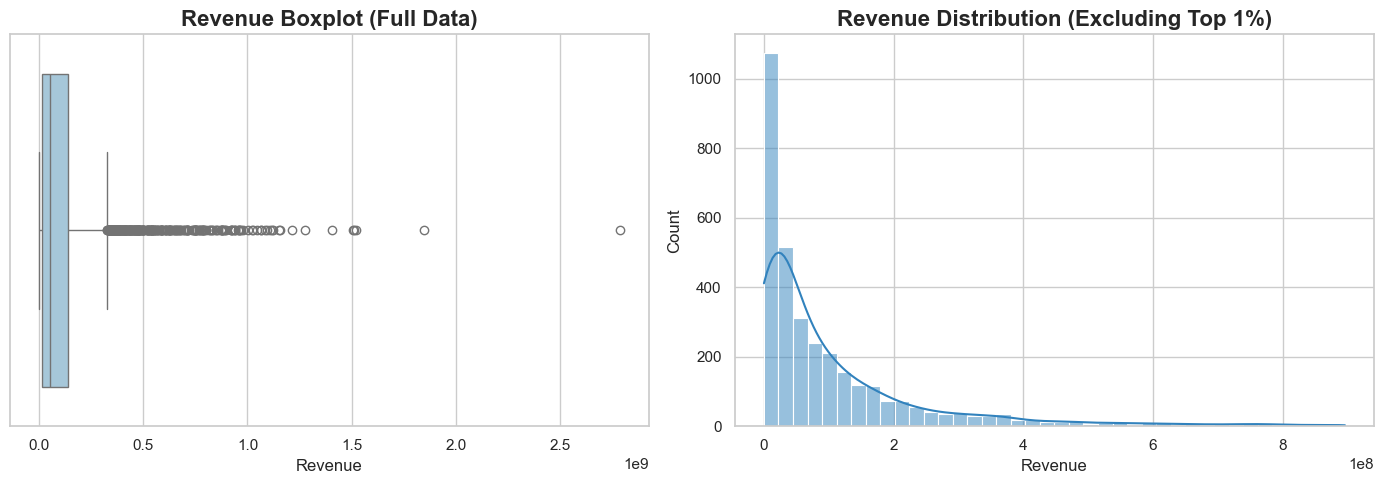

In [130]:
# 1. Limpieza de Revenue como numérico
revenue_clean = pd.to_numeric(df1['revenue'], errors='coerce')

# --- EXCLUSIÓN DEL ÚLTIMO 1% ---
q99 = revenue_clean.quantile(0.99)
outlier_99 = revenue_clean > q99

# 2. Método IQR
q1 = revenue_clean.quantile(0.25)
q3 = revenue_clean.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_iqr = (revenue_clean < lower) | (revenue_clean > upper)

# 3. Método Z-score (sobre valores no nulos)
mu = revenue_clean.mean()
sigma = revenue_clean.std()
z_scores = (revenue_clean - mu) / sigma
outlier_z = z_scores.abs() > 3

# --- IMPRESIÓN DE RESULTADOS ---
print('Revenue summary:')
print(revenue_clean.describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))

print('\n--- Outlier Detection ---')
print(f'Percentile 99 (Top 1%): > {round(q99, 2)}')
print(f'Registros excluidos (Top 1%): {int(outlier_99.sum())}')
print(f'IQR bounds: [{round(lower, 2)}, {round(upper, 2)}]')
print(f'IQR outliers: {int(outlier_iqr.sum())}')
print(f'Z-score outliers (|z|>3): {int(outlier_z.sum())}')

# Mostrar los 15 más altos
title_col = next((c for c in ['title', 'original_title', 'movie_title', 'name'] if c in df1.columns), None)
cols_to_show = ['revenue'] + ([title_col] if title_col else [])
print('\nTop 15 highest Revenue:')
print(df1.loc[revenue_clean.nlargest(15).index, cols_to_show])

# --- REVISIÓN VISUAL ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot original (para ver todos los puntos)
sns.boxplot(x=revenue_clean, ax=axes[0], color='#9ecae1')
axes[0].set_title('Revenue Boxplot (Full Data)')
axes[0].set_xlabel('Revenue')

# Histograma EXCLUYENDO el último 1% para ver mejor la masa de datos
sns.histplot(revenue_clean[~outlier_99].dropna(), bins=40, kde=True, ax=axes[1], color='#3182bd')
axes[1].set_title('Revenue Distribution (Excluding Top 1%)')
axes[1].set_xlabel('Revenue')

plt.tight_layout()
plt.show()

## limpieza de outlier en budget
Limpiamos 0's, y el último cuantil

In [131]:
zero_budget_count = (pd.to_numeric(df1['budget'], errors='coerce') == 0).sum()
total_rows = len(df1)
print(f'Rows with budget = 0: {zero_budget_count}')
print(f'Percentage: {zero_budget_count/total_rows:.2%}')

Rows with budget = 0: 147
Percentage: 4.36%


In [132]:
df1.drop(df1[pd.to_numeric(df1['budget'], errors='coerce') == 0].index, inplace=True)

Budget summary:
count    3.228000e+03
mean     4.066642e+07
std      4.439840e+07
min      1.000000e+00
25%      1.050000e+07
50%      2.500000e+07
75%      5.500000e+07
90%      9.500000e+07
95%      1.400000e+08
99%      2.000000e+08
max      3.800000e+08
Name: budget, dtype: float64

IQR bounds: {'lower': -56250000.0, 'upper': 121750000.0}
IQR outliers: 216
Z-score outliers (|z|>3): 76

Top 15 highest budgets:
       budget
17  380000000
1   300000000
7   280000000
10  270000000
4   260000000
6   260000000
5   258000000
13  255000000
3   250000000
8   250000000
9   250000000
19  250000000
22  250000000
26  250000000
46  250000000


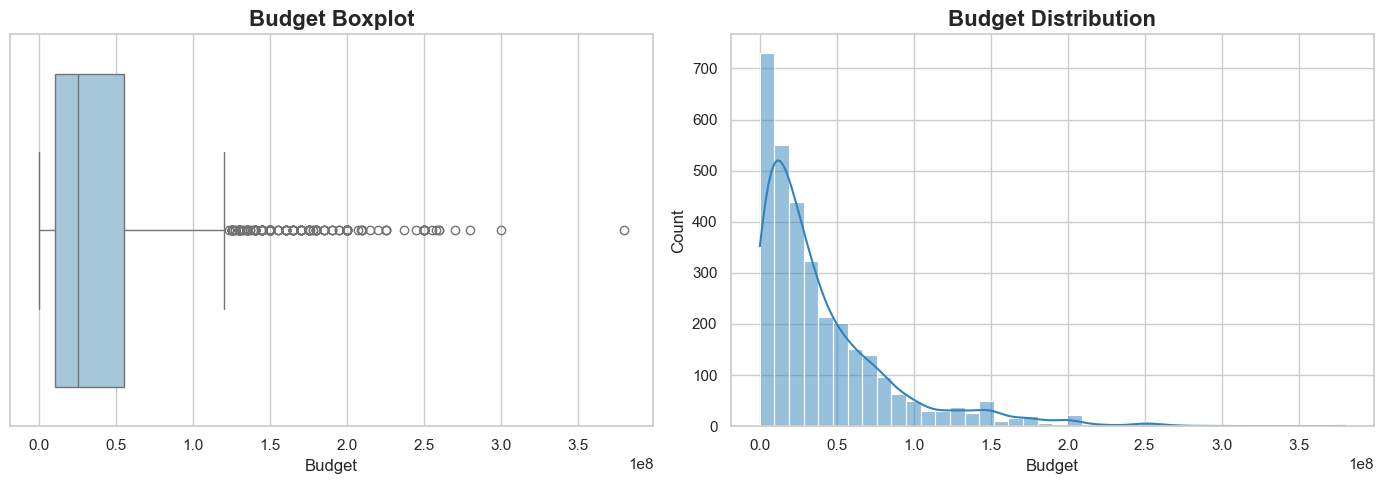

In [133]:
# Clean budget as numeric
budget_clean = pd.to_numeric(df1['budget'], errors='coerce')

# IQR method
q1 = budget_clean.quantile(0.25)
q3 = budget_clean.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_iqr = (budget_clean < lower) | (budget_clean > upper)

# Z-score method (on non-null values)
mu = budget_clean.mean()
sigma = budget_clean.std()
z_scores = (budget_clean - mu) / sigma
outlier_z = z_scores.abs() > 3

print('Budget summary:')
print(budget_clean.describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))
print('\nIQR bounds:', {'lower': round(lower, 2), 'upper': round(upper, 2)})
print('IQR outliers:', int(outlier_iqr.sum()))
print('Z-score outliers (|z|>3):', int(outlier_z.sum()))

# Show top high-budget potential outliers
title_col = next((c for c in ['title', 'original_title', 'movie_title', 'name'] if c in df1.columns), None)
cols_to_show = ['budget'] + ([title_col] if title_col else [])
print('\nTop 15 highest budgets:')
print(df1.loc[budget_clean.nlargest(15).index, cols_to_show])

# Visual review
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=budget_clean, ax=axes[0], color='#9ecae1')
axes[0].set_title('Budget Boxplot')
axes[0].set_xlabel('Budget')

sns.histplot(budget_clean.dropna(), bins=40, kde=True, ax=axes[1], color='#3182bd')
axes[1].set_title('Budget Distribution')
axes[1].set_xlabel('Budget')

plt.tight_layout()
plt.show()

Budget summary:
count    3.228000e+03
mean     4.066642e+07
std      4.439840e+07
min      1.000000e+00
25%      1.050000e+07
50%      2.500000e+07
75%      5.500000e+07
90%      9.500000e+07
95%      1.400000e+08
99%      2.000000e+08
max      3.800000e+08
Name: budget, dtype: float64

--- Outlier Detection for Budget ---
Percentile 99 (Top 1%): > 200000000.0
Registros excluidos (Top 1%): 27
IQR bounds: [-56250000.0, 121750000.0]
IQR outliers: 216
Z-score outliers (|z|>3): 76

Top 15 highest Budgets:
       budget
17  380000000
1   300000000
7   280000000
10  270000000
4   260000000
6   260000000
5   258000000
13  255000000
3   250000000
8   250000000
9   250000000
19  250000000
22  250000000
26  250000000
46  250000000


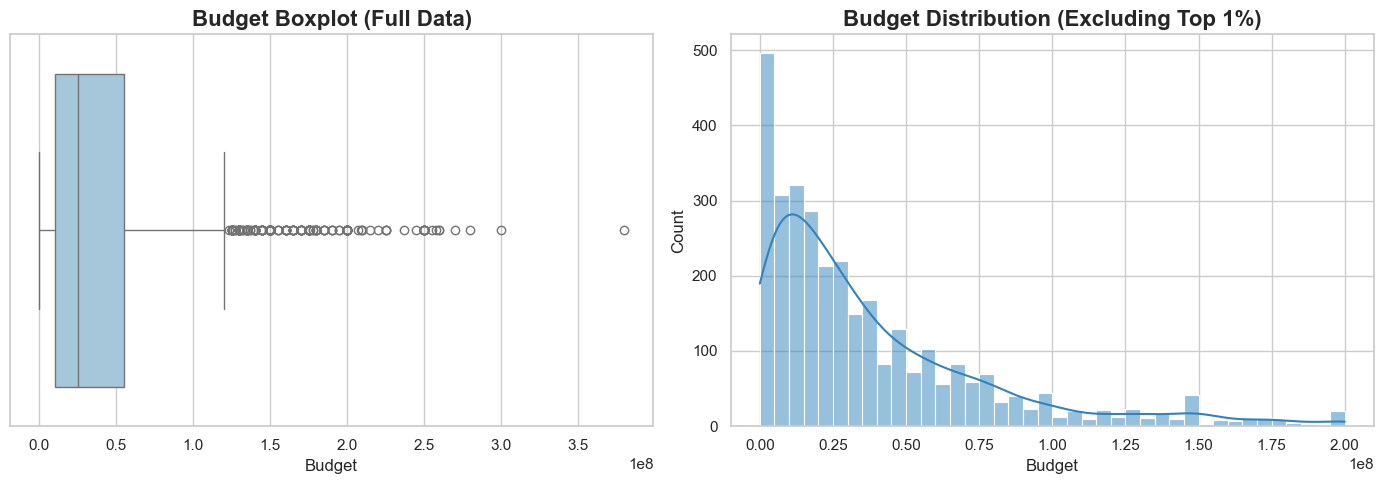

In [134]:
# 1. Limpieza de Budget como numérico
budget_clean = pd.to_numeric(df1['budget'], errors='coerce')

# --- EXCLUSIÓN DEL ÚLTIMO 1% (Percentil 99) ---
q99_budget = budget_clean.quantile(0.99)
outlier_99_budget = budget_clean > q99_budget

# 2. Método IQR
q1 = budget_clean.quantile(0.25)
q3 = budget_clean.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_iqr = (budget_clean < lower) | (budget_clean > upper)

# 3. Método Z-score (sobre valores no nulos)
mu = budget_clean.mean()
sigma = budget_clean.std()
z_scores = (budget_clean - mu) / sigma
outlier_z = z_scores.abs() > 3

# --- IMPRESIÓN DE RESULTADOS ---
print('Budget summary:')
print(budget_clean.describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))

print('\n--- Outlier Detection for Budget ---')
print(f'Percentile 99 (Top 1%): > {round(q99_budget, 2)}')
print(f'Registros excluidos (Top 1%): {int(outlier_99_budget.sum())}')
print(f'IQR bounds: [{round(lower, 2)}, {round(upper, 2)}]')
print(f'IQR outliers: {int(outlier_iqr.sum())}')
print(f'Z-score outliers (|z|>3): {int(outlier_z.sum())}')

# Mostrar los 15 presupuestos más altos
title_col = next((c for c in ['title', 'original_title', 'movie_title', 'name'] if c in df1.columns), None)
cols_to_show = ['budget'] + ([title_col] if title_col else [])
print('\nTop 15 highest Budgets:')
print(df1.loc[budget_clean.nlargest(15).index, cols_to_show])

# --- REVISIÓN VISUAL ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot original (muestra todos los puntos para ver la extensión total)
sns.boxplot(x=budget_clean, ax=axes[0], color='#9ecae1')
axes[0].set_title('Budget Boxplot (Full Data)')
axes[0].set_xlabel('Budget')

# Histograma EXCLUYENDO el último 1% (zoom en el grueso de la distribución)
sns.histplot(budget_clean[~outlier_99_budget].dropna(), bins=40, kde=True, ax=axes[1], color='#3182bd')
axes[1].set_title('Budget Distribution (Excluding Top 1%)')
axes[1].set_xlabel('Budget')

plt.tight_layout()
plt.show()

## clasificacion de la columna de fechas

In [135]:
# Handle possible typo in column name
if 'release_date' in df1.columns:
    date_col = 'release_date'
elif 'relase_date' in df1.columns:
    date_col = 'relase_date'
else:
    raise KeyError("No release date column found. Expected 'release_date' or 'relase_date'.")

# 1) Standardize to datetime and YYYY-MM-DD
release_dt = pd.to_datetime(df1[date_col], errors='coerce')
df1['release_date_std'] = release_dt.dt.strftime('%Y-%m-%d')

# 2) Extract year
df1['release_year'] = release_dt.dt.year

# 3) Extract month name (e.g., October)
df1['release_month'] = release_dt.dt.month_name()

# 4) One-hot flag for business day
# Business day: Monday(0) to Friday(4)
df1['is_business_day_release'] = release_dt.dt.weekday.isin([0, 1, 2, 3, 4]).astype('Int64')

# 5) Season grouping based on month
# Northern Hemisphere seasons (United States)
# Winter:  Dec, Jan, Feb
# Spring:  Mar, Apr, May
# Summer:  Jun, Jul, Aug
# Fall:    Sep, Oct, Nov
def get_season(month):
    if pd.isna(month):
        return pd.NA
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    else:
        return 'Other'

df1['release_season'] = release_dt.dt.month.map(get_season)

print(df1[[date_col, 'release_date_std', 'release_year', 'release_month', 'release_season', 'is_business_day_release']].head(10))

  release_date release_date_std  release_year release_month release_season  \
0   2009-12-10       2009-12-10          2009      December         Winter   
1   2007-05-19       2007-05-19          2007           May         Spring   
2   2015-10-26       2015-10-26          2015       October           Fall   
3   2012-07-16       2012-07-16          2012          July         Summer   
4   2012-03-07       2012-03-07          2012         March         Spring   
5   2007-05-01       2007-05-01          2007           May         Spring   
6   2010-11-24       2010-11-24          2010      November           Fall   
7   2015-04-22       2015-04-22          2015         April         Spring   
8   2009-07-07       2009-07-07          2009          July         Summer   
9   2016-03-23       2016-03-23          2016         March         Spring   

   is_business_day_release  
0                        1  
1                        0  
2                        1  
3                        

## Clasificicacion por generos

In [136]:
df1['genres'].value_counts().head(30)

genres
Drama                                 204
Comedy                                197
Drama, Romance                         96
Comedy, Romance                        87
Comedy, Drama                          70
Comedy, Drama, Romance                 63
Horror, Thriller                       61
Horror                                 36
Drama, Thriller                        35
Action, Thriller                       32
Drama, History                         32
Crime, Drama, Thriller                 30
Action, Crime, Thriller                25
Adventure, Action, Thriller            24
Drama, Comedy                          24
Documentary                            22
Comedy, Crime                          22
Drama, Crime                           22
Comedy, Family                         21
Crime, Drama                           21
Animation, Family                      20
Action, Crime, Drama, Thriller         20
Drama, Comedy, Romance                 20
Animation, Comedy, Family  

In [137]:
genre_counts = (
    df['genres']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .loc[lambda s: s.ne('')]
    .value_counts()
)

genre_counts

genres
Drama              2297
Comedy             1722
Thriller           1274
Action             1154
Romance             894
Adventure           790
Crime               696
Science Fiction     535
Horror              519
Family              513
Fantasy             424
Mystery             348
Animation           234
History             197
Music               185
War                 144
Documentary         110
Western              82
Foreign              34
TV Movie              8
Name: count, dtype: int64

In [138]:
df1.columns

Index(['budget', 'genres', 'original_language', 'popularity',
       'production_companies', 'release_date', 'revenue', 'runtime',
       'vote_average', 'vote_count', 'main_language_english', 'big_studio',
       'release_date_std', 'release_year', 'release_month',
       'is_business_day_release', 'release_season'],
      dtype='object')

**Mapeamos los géneros y los agrupamos**

In [139]:
genre_map = {
    'science fiction': 'Fantasy',
    'thriller': 'Horror',
    'mystery': 'Crime',
    'music': 'Other',
    'war': 'Other',
    'documentary': 'Other',
    'western': 'Other',
    'foreign': 'Other',
    'tv movie': 'Other',
    'animation' : 'Family',
    'history' : 'Other'
}

genre_counts_generalized = (
    df['genres']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .loc[lambda s: s.ne('')]
    .map(lambda g: genre_map.get(g.lower(), g))
    .value_counts()
)


genre_counts_generalized


genres
Drama        2297
Horror       1793
Comedy       1722
Action       1154
Crime        1044
Fantasy       959
Romance       894
Adventure     790
Other         760
Family        747
Name: count, dtype: int64

In [140]:
#Ahora creamos una columna one-hot para cada género generalizado, asignando 1 si la película pertenece a ese género y 0 en caso contrario.
for genre in genre_counts_generalized.index:
    df1[f'genre_{genre}'] = df1['genres'].apply(
        lambda x: 1 if pd.notna(x) and genre in [
            genre_map.get(g.strip().lower(), g.strip())
            for g in x.split(',')
        ] else 0
    )
df1.head()

,budget,genres,original_language,popularity,production_companies,release_date,revenue,runtime,vote_average,vote_count,...,genre_Drama,genre_Horror,genre_Comedy,genre_Action,genre_Crime,genre_Fantasy,genre_Romance,genre_Adventure,genre_Other,genre_Family
0,237000000,"Action, Adventure, Fantasy, Science Fiction",en,150.437577,"Ingenious Film Partners, Twentieth Century Fox...",2009-12-10,2787965087,162.0,7.2,11800,...,0,0,0,1,0,1,0,1,0,0
1,300000000,"Adventure, Fantasy, Action",en,139.082615,"Walt Disney Pictures, Jerry Bruckheimer Films,...",2007-05-19,961000000,169.0,6.9,4500,...,0,0,0,1,0,1,0,1,0,0
2,245000000,"Action, Adventure, Crime",en,107.376788,"Columbia Pictures, Danjaq, B24",2015-10-26,880674609,148.0,6.3,4466,...,0,0,0,1,1,0,0,1,0,0
3,250000000,"Action, Crime, Drama, Thriller",en,112.312950,"Legendary Pictures, Warner Bros., DC Entertain...",2012-07-16,1084939099,165.0,7.6,9106,...,1,1,0,1,1,0,0,0,0,0
4,260000000,"Action, Adventure, Science Fiction",en,43.926995,Walt Disney Pictures,2012-03-07,284139100,132.0,6.1,2124,...,0,0,0,1,0,1,0,1,0,0


# estadistica descriptiva

*Creamos Log-Budget*
log1p(budget) first: budget_log = log(1 + budget)

In [141]:
log_budget = np.log(1 + df1['budget'].dropna())
log_budget.describe()

count    3228.000000
mean       16.800614
std         1.661577
min         0.693147
25%        16.166886
50%        17.034386
75%        17.822844
max        19.755682
Name: budget, dtype: float64

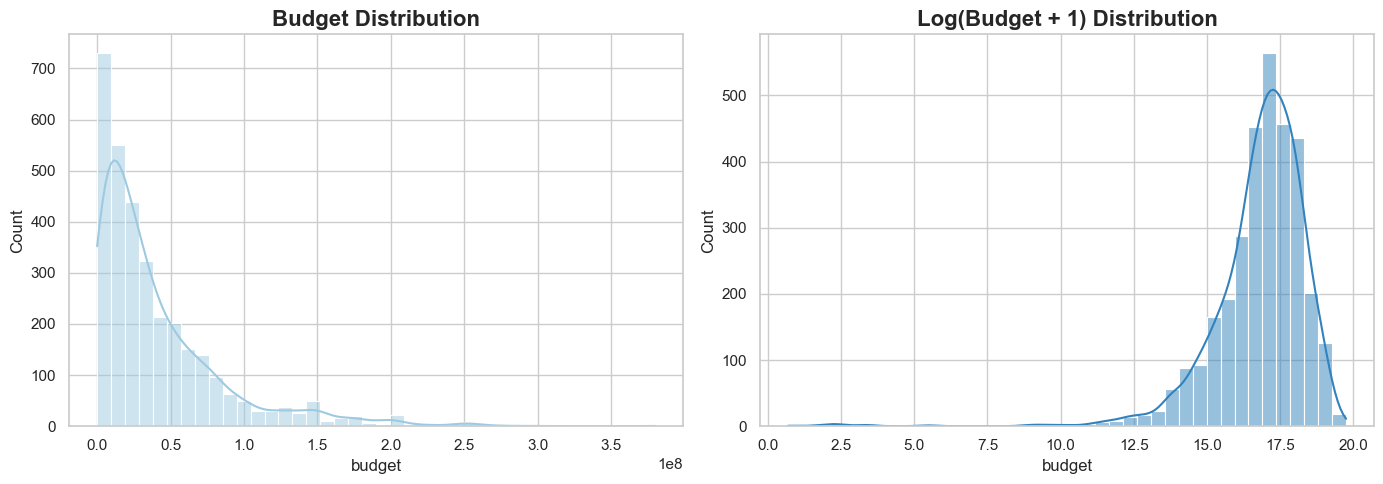

In [142]:
#Creamos un plot de budget y otro de budget logarítmico para comparar la distribución y detectar mejor los outliers.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df1['budget'].dropna(), bins=40, kde=True, ax=axes[0], color='#9ecae1')
axes[0].set_title('Budget Distribution')   
sns.histplot(log_budget, bins=40, kde=True, ax=axes[1], color='#3182bd')
axes[1].set_title('Log(Budget + 1) Distribution')
plt.tight_layout()
plt.show()  

In [143]:
#Ahora se puede observar que la distribución logarítmica es más simétrica y tiene menos outliers extremos, lo que facilita el análisis estadístico y la modelización. Usaremos standard scaler.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
log_budget_scaled = scaler.fit_transform(log_budget.values.reshape(-1, 1))
df1['log_budget_scaled'] = log_budget_scaled
df1.head()

,budget,genres,original_language,popularity,production_companies,release_date,revenue,runtime,vote_average,vote_count,...,genre_Horror,genre_Comedy,genre_Action,genre_Crime,genre_Fantasy,genre_Romance,genre_Adventure,genre_Other,genre_Family,log_budget_scaled
0,237000000,"Action, Adventure, Fantasy, Science Fiction",en,150.437577,"Ingenious Film Partners, Twentieth Century Fox...",2009-12-10,2787965087,162.0,7.2,11800,...,0,0,1,0,1,0,1,0,0,1.494570
1,300000000,"Adventure, Fantasy, Action",en,139.082615,"Walt Disney Pictures, Jerry Bruckheimer Films,...",2007-05-19,961000000,169.0,6.9,4500,...,0,0,1,0,1,0,1,0,0,1.636458
2,245000000,"Action, Adventure, Crime",en,107.376788,"Columbia Pictures, Danjaq, B24",2015-10-26,880674609,148.0,6.3,4466,...,0,0,1,1,0,0,1,0,0,1.514553
3,250000000,"Action, Crime, Drama, Thriller",en,112.312950,"Legendary Pictures, Warner Bros., DC Entertain...",2012-07-16,1084939099,165.0,7.6,9106,...,1,0,1,1,0,0,0,0,0,1.526713
4,260000000,"Action, Adventure, Science Fiction",en,43.926995,Walt Disney Pictures,2012-03-07,284139100,132.0,6.1,2124,...,0,0,1,0,1,0,1,0,0,1.550321


## estudiamos popularity

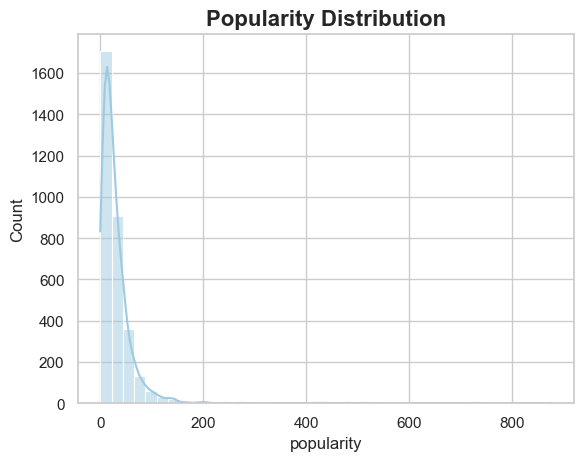

In [144]:
#Ploteamos la columna popularity para observar su distribución y detectar posibles outliers.
sns.histplot(df1['popularity'].dropna(), bins=40, kde=True, color='#9ecae1')
plt.title('Popularity Distribution')
plt.show()

In [145]:
#Aplicamos logaritmo a popularity para reducir la asimetría y facilitar el análisis estadístico.
log_popularity = np.log(1 + df1['popularity'].dropna())

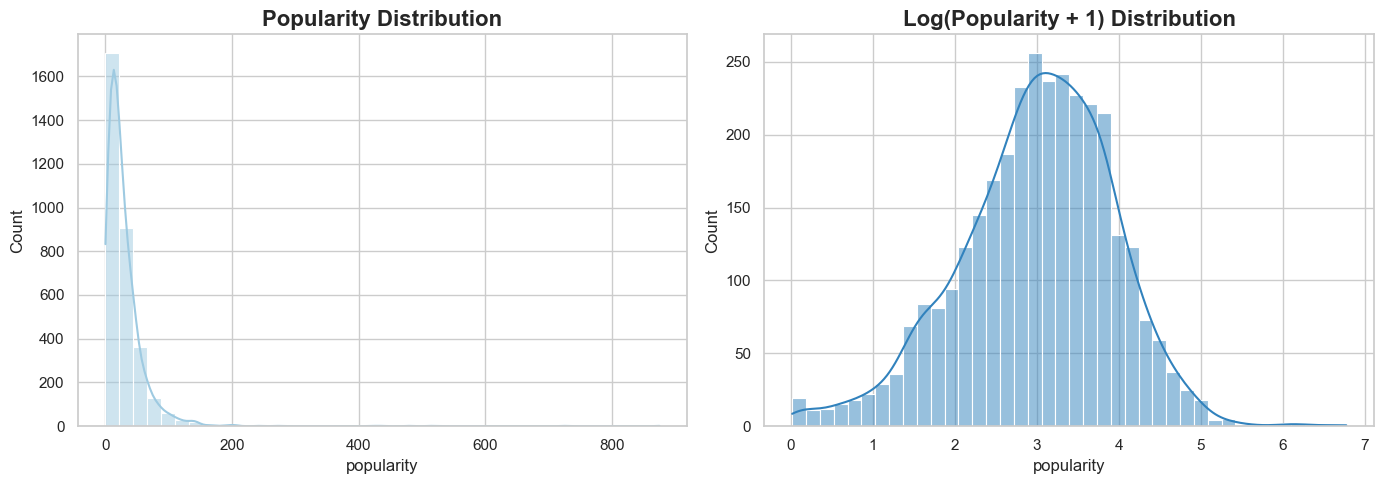

In [146]:
#Creamos un plot de popularity y otro de popularity logarítmico para comparar la distribución y detectar mejor los outliers.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df1['popularity'].dropna(), bins=40, kde=True, ax=axes[0], color='#9ecae1')
axes[0].set_title('Popularity Distribution')
sns.histplot(log_popularity, bins=40, kde=True, ax=axes[1], color='#3182bd')
axes[1].set_title('Log(Popularity + 1) Distribution')
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

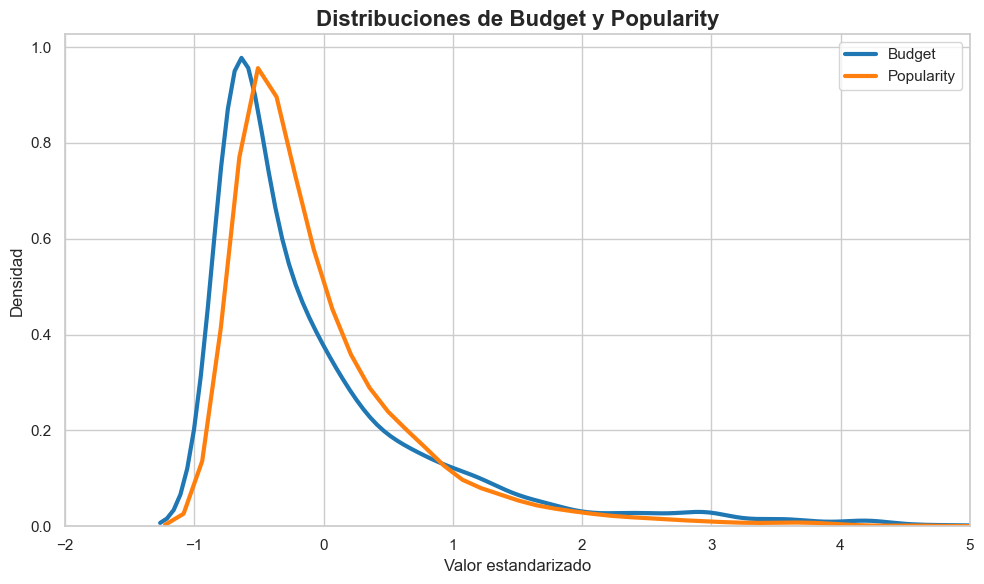

In [147]:
# seleccionar variables
df_dist = df[["budget", "popularity"]].dropna()

# estandarizar
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_dist),
    columns=["budget", "popularity"]
)
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

# curvas KDE
sns.kdeplot(
    df_scaled["budget"],
    label="Budget",
    linewidth=3,
    color="#1f77b4"
)

sns.kdeplot(
    df_scaled["popularity"],
    label="Popularity",
    linewidth=3,
    color="#ff7f0e"
)

# limitar eje X para que no haya tanto espacio vacío
plt.xlim(-2, 5)

plt.title("Distribuciones de Budget y Popularity", fontsize=16, weight="bold")
plt.xlabel("Valor estandarizado")
plt.ylabel("Densidad")

plt.legend(frameon=True)
plt.tight_layout()
plt.show

In [148]:
#Aplicamos StandardScaler a popularity logarítmico para normalizarlo.
log_popularity_scaled = scaler.fit_transform(log_popularity.values.reshape(-1, 1))
df1["log_popularity_scaled"] = log_popularity_scaled
df1.head()

,budget,genres,original_language,popularity,production_companies,release_date,revenue,runtime,vote_average,vote_count,...,genre_Comedy,genre_Action,genre_Crime,genre_Fantasy,genre_Romance,genre_Adventure,genre_Other,genre_Family,log_budget_scaled,log_popularity_scaled
0,237000000,"Action, Adventure, Fantasy, Science Fiction",en,150.437577,"Ingenious Film Partners, Twentieth Century Fox...",2009-12-10,2787965087,162.0,7.2,11800,...,0,1,0,1,0,1,0,0,1.494570,2.159066
1,300000000,"Adventure, Fantasy, Action",en,139.082615,"Walt Disney Pictures, Jerry Bruckheimer Films,...",2007-05-19,961000000,169.0,6.9,4500,...,0,1,0,1,0,1,0,0,1.636458,2.075846
2,245000000,"Action, Adventure, Crime",en,107.376788,"Columbia Pictures, Danjaq, B24",2015-10-26,880674609,148.0,6.3,4466,...,0,1,1,0,0,1,0,0,1.514553,1.801847
3,250000000,"Action, Crime, Drama, Thriller",en,112.312950,"Legendary Pictures, Warner Bros., DC Entertain...",2012-07-16,1084939099,165.0,7.6,9106,...,0,1,1,0,0,0,0,0,1.526713,1.849404
4,260000000,"Action, Adventure, Science Fiction",en,43.926995,Walt Disney Pictures,2012-03-07,284139100,132.0,6.1,2124,...,0,1,0,1,0,1,0,0,1.550321,0.861632


# Estudiamos vote count

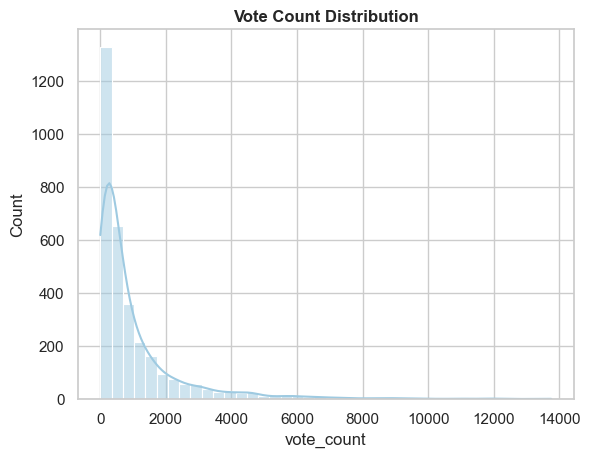

In [149]:
#Creamos un histograma de vote_count para observar su distribución y detectar posibles outliers.
sns.histplot(df1['vote_count'].dropna(), bins=40, kde=True, color='#9ecae1')
plt.title('Vote Count Distribution')
plt.show()

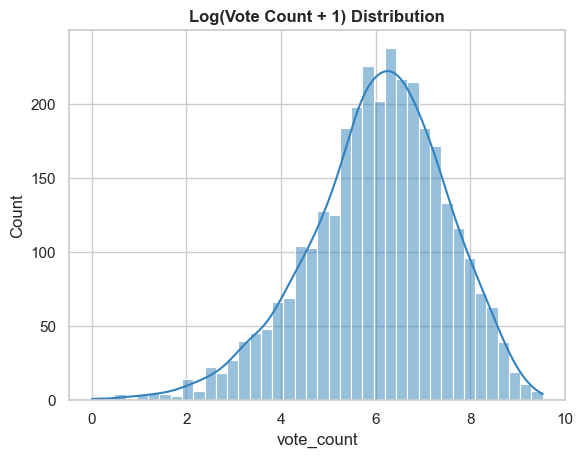

In [150]:
#Aplicamos logaritmo a vote_count para reducir la asimetría y facilitar el análisis estadístico.
log_vote_count = np.log(1 + df1['vote_count'].dropna())
#Revisamos el histograma de vote_count logarítmico para confirmar que la transformación ha reducido la asimetría y los outliers extremos.
sns.histplot(log_vote_count, bins=40, kde=True, color='#3182bd')
plt.title('Log(Vote Count + 1) Distribution')  
plt.show()

In [151]:
#Escalamos vote_count logarítmico con StandardScaler para normalizarlo.
log_vote_count_scaled = scaler.fit_transform(log_vote_count.values.reshape(-1, 1))
df1['log_vote_count_scaled'] = log_vote_count_scaled
df1.head()

,budget,genres,original_language,popularity,production_companies,release_date,revenue,runtime,vote_average,vote_count,...,genre_Action,genre_Crime,genre_Fantasy,genre_Romance,genre_Adventure,genre_Other,genre_Family,log_budget_scaled,log_popularity_scaled,log_vote_count_scaled
0,237000000,"Action, Adventure, Fantasy, Science Fiction",en,150.437577,"Ingenious Film Partners, Twentieth Century Fox...",2009-12-10,2787965087,162.0,7.2,11800,...,1,0,1,0,1,0,0,1.494570,2.159066,2.301360
1,300000000,"Adventure, Fantasy, Action",en,139.082615,"Walt Disney Pictures, Jerry Bruckheimer Films,...",2007-05-19,961000000,169.0,6.9,4500,...,1,0,1,0,1,0,0,1.636458,2.075846,1.637068
2,245000000,"Action, Adventure, Crime",en,107.376788,"Columbia Pictures, Danjaq, B24",2015-10-26,880674609,148.0,6.3,4466,...,1,1,0,0,1,0,0,1.514553,1.801847,1.631842
3,250000000,"Action, Crime, Drama, Thriller",en,112.312950,"Legendary Pictures, Warner Bros., DC Entertain...",2012-07-16,1084939099,165.0,7.6,9106,...,1,1,0,0,0,0,0,1.526713,1.849404,2.122765
4,260000000,"Action, Adventure, Science Fiction",en,43.926995,Walt Disney Pictures,2012-03-07,284139100,132.0,6.1,2124,...,1,0,1,0,1,0,0,1.550321,0.861632,1.119818


## Estudiamos Revenue

In [152]:
#Dropeamos todos los valores de revenue que sean 0, ya que no aportan información útil para el análisis y pueden distorsionar la distribución.
df1.drop(df1[pd.to_numeric(df1['revenue'], errors='coerce') == 0].index, inplace=True)

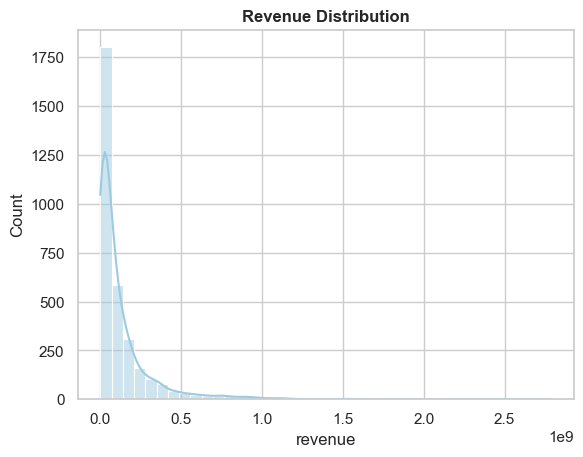

In [153]:
#Histograma de revenue para observar su distribución y detectar posibles outliers.
sns.histplot(df1['revenue'].dropna(), bins=40, kde=True, color='#9ecae1')
plt.title('Revenue Distribution')
plt.show()

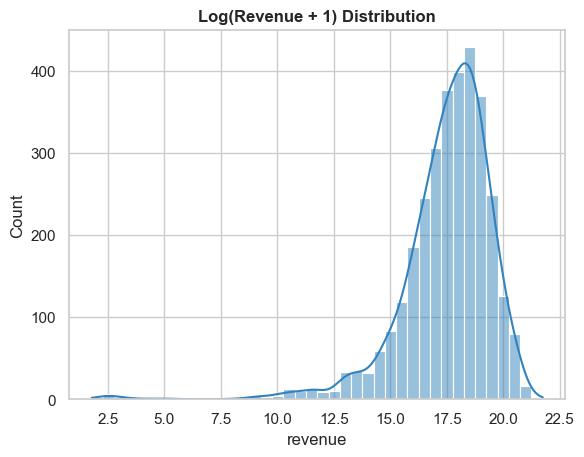

In [154]:
#Aplicamos logaritmo a revenue para reducir la asimetría y facilitar el análisis estadístico.
log_revenue = np.log(1 + df1['revenue'].dropna())
#Revisamos el histograma de revenue logarítmico para confirmar que la transformación ha reducido la asimetría y los outliers extremos.
sns.histplot(log_revenue, bins=40, kde=True, color='#3182bd')
plt.title('Log(Revenue + 1) Distribution')
plt.show()

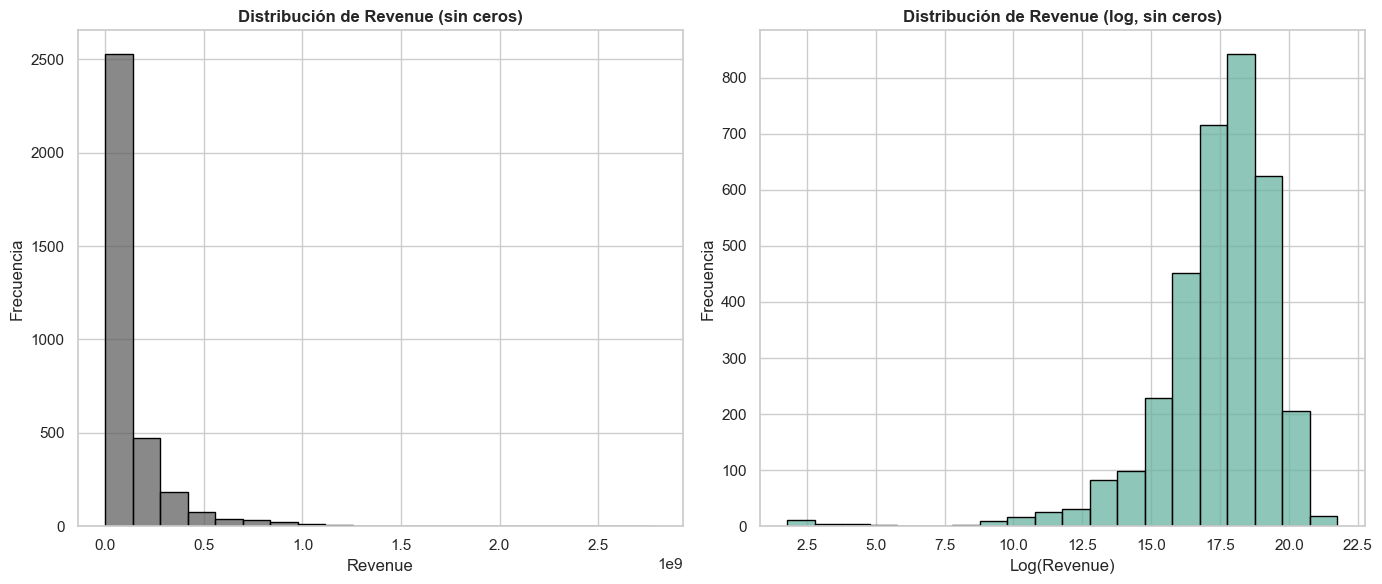

In [155]:
sns.set_theme(style="whitegrid")

#  Filtrar ceros
df_sin_ceros = df[df["revenue"] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# 📊 Histograma normal (sin ceros)
sns.histplot(
    df_sin_ceros["revenue"],
    bins=20,
    color="0.38",
    edgecolor="black",
    ax=axes[0]
)

axes[0].set_title("Distribución de Revenue (sin ceros)")
axes[0].set_xlabel("Revenue")
axes[0].set_ylabel("Frecuencia")

# 📊 Histograma log (sin ceros)
sns.histplot(
    np.log1p(df_sin_ceros["revenue"]),
    bins=20,
    color="#69b3a2",
    edgecolor="black",
    ax=axes[1]
)

axes[1].set_title("Distribución de Revenue (log, sin ceros)")
axes[1].set_xlabel("Log(Revenue)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()

plt.show()

In [156]:
df1["log_revenue"] = log_revenue
df1.head()

,budget,genres,original_language,popularity,production_companies,release_date,revenue,runtime,vote_average,vote_count,...,genre_Crime,genre_Fantasy,genre_Romance,genre_Adventure,genre_Other,genre_Family,log_budget_scaled,log_popularity_scaled,log_vote_count_scaled,log_revenue
0,237000000,"Action, Adventure, Fantasy, Science Fiction",en,150.437577,"Ingenious Film Partners, Twentieth Century Fox...",2009-12-10,2787965087,162.0,7.2,11800,...,0,1,0,1,0,0,1.494570,2.159066,2.301360,21.748578
1,300000000,"Adventure, Fantasy, Action",en,139.082615,"Walt Disney Pictures, Jerry Bruckheimer Films,...",2007-05-19,961000000,169.0,6.9,4500,...,0,1,0,1,0,0,1.636458,2.075846,1.637068,20.683485
2,245000000,"Action, Adventure, Crime",en,107.376788,"Columbia Pictures, Danjaq, B24",2015-10-26,880674609,148.0,6.3,4466,...,1,0,0,1,0,0,1.514553,1.801847,1.631842,20.596199
3,250000000,"Action, Crime, Drama, Thriller",en,112.312950,"Legendary Pictures, Warner Bros., DC Entertain...",2012-07-16,1084939099,165.0,7.6,9106,...,1,0,0,0,0,0,1.526713,1.849404,2.122765,20.804790
4,260000000,"Action, Adventure, Science Fiction",en,43.926995,Walt Disney Pictures,2012-03-07,284139100,132.0,6.1,2124,...,0,1,0,1,0,0,1.550321,0.861632,1.119818,19.464974


## Grafico de generos con mayores revenues

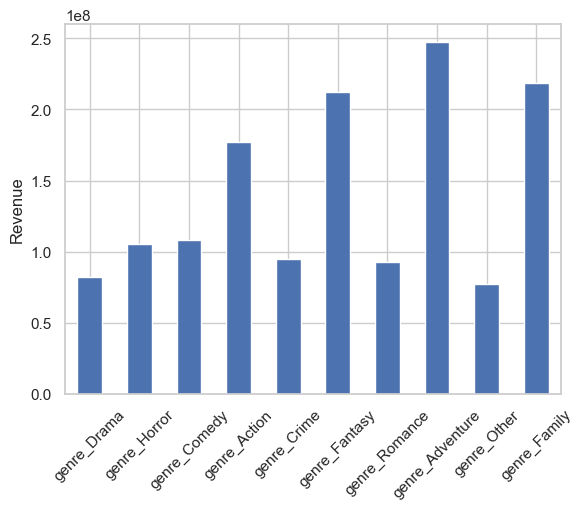

In [157]:
import pandas as pd
import matplotlib.pyplot as plt

genre_cols = [col for col in df1.columns if col.startswith('genre_')]

revenues = {g: df1[df1[g]==1]['revenue'].mean() for g in genre_cols}

pd.Series(revenues).plot(kind='bar')

plt.xticks(rotation=45)
plt.ylabel('Revenue')
plt.show()

## Grafico de revenue segun mes de lanzamiento

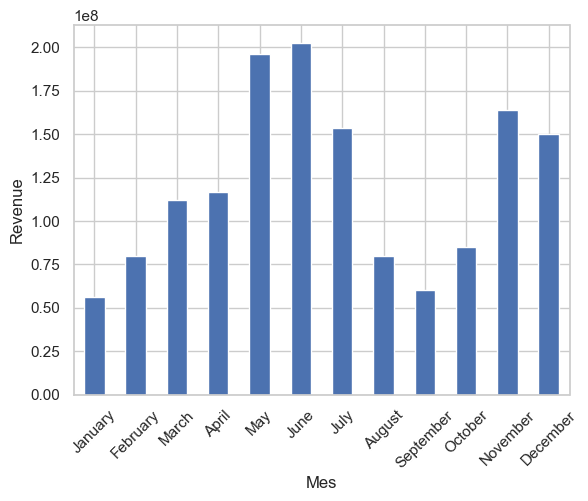

In [158]:
import matplotlib.pyplot as plt

orden = ['January','February','March','April','May','June',
         'July','August','September','October','November','December']

df1.groupby('release_month')['revenue'].mean().reindex(orden).plot(kind='bar')

plt.xlabel('Mes')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

budget popularidad 

In [159]:
df1.columns

Index(['budget', 'genres', 'original_language', 'popularity',
       'production_companies', 'release_date', 'revenue', 'runtime',
       'vote_average', 'vote_count', 'main_language_english', 'big_studio',
       'release_date_std', 'release_year', 'release_month',
       'is_business_day_release', 'release_season', 'genre_Drama',
       'genre_Horror', 'genre_Comedy', 'genre_Action', 'genre_Crime',
       'genre_Fantasy', 'genre_Romance', 'genre_Adventure', 'genre_Other',
       'genre_Family', 'log_budget_scaled', 'log_popularity_scaled',
       'log_vote_count_scaled', 'log_revenue'],
      dtype='object')

In [160]:
columnas_utiles=['log_revenue',"log_budget_scaled",'release_year', 'release_month',
       'is_business_day_release', 'genre_Drama', 'genre_Horror',
       'genre_Comedy', 'genre_Action', 'genre_Crime', 'genre_Fantasy',
       'genre_Romance', 'genre_Adventure', 'genre_Family', 'genre_Other','big_studio','log_popularity_scaled','vote_average','main_language_english',"release_season"]

data=df1[columnas_utiles]

## matriz de correlacion

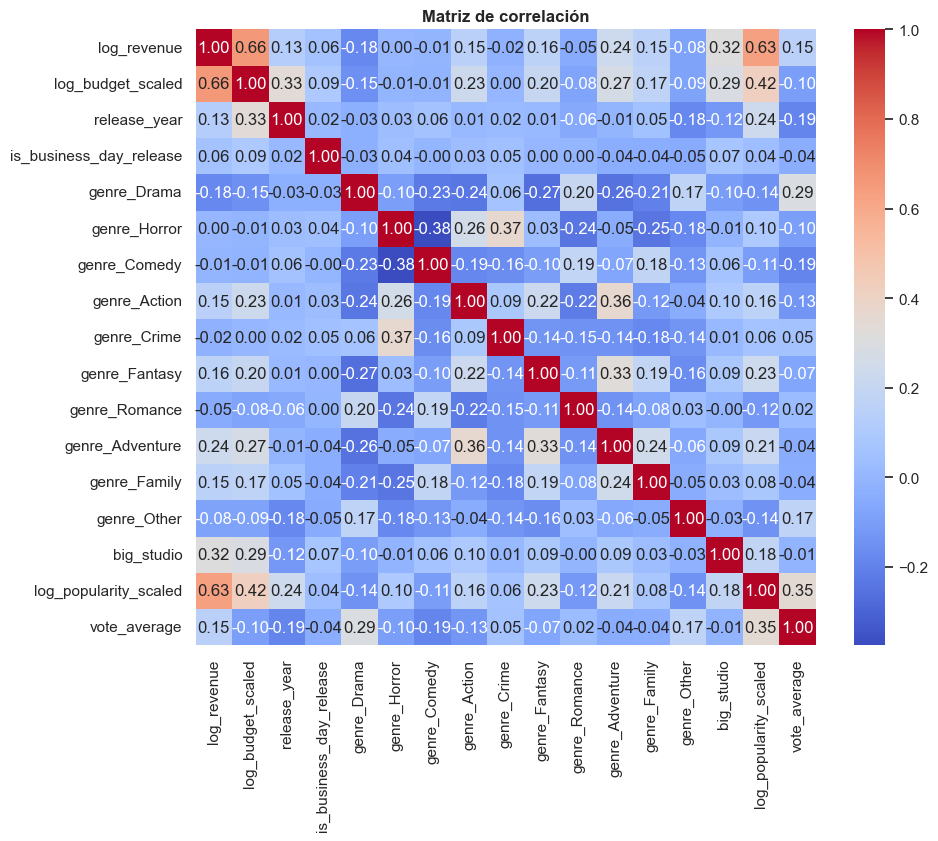

In [161]:


def heatmap_corr(df):
    corr = df.select_dtypes(include='number').corr()
    
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
    
    plt.title('Matriz de correlación')
    plt.show()
heatmap_corr(data)    

## graficos de dispersion

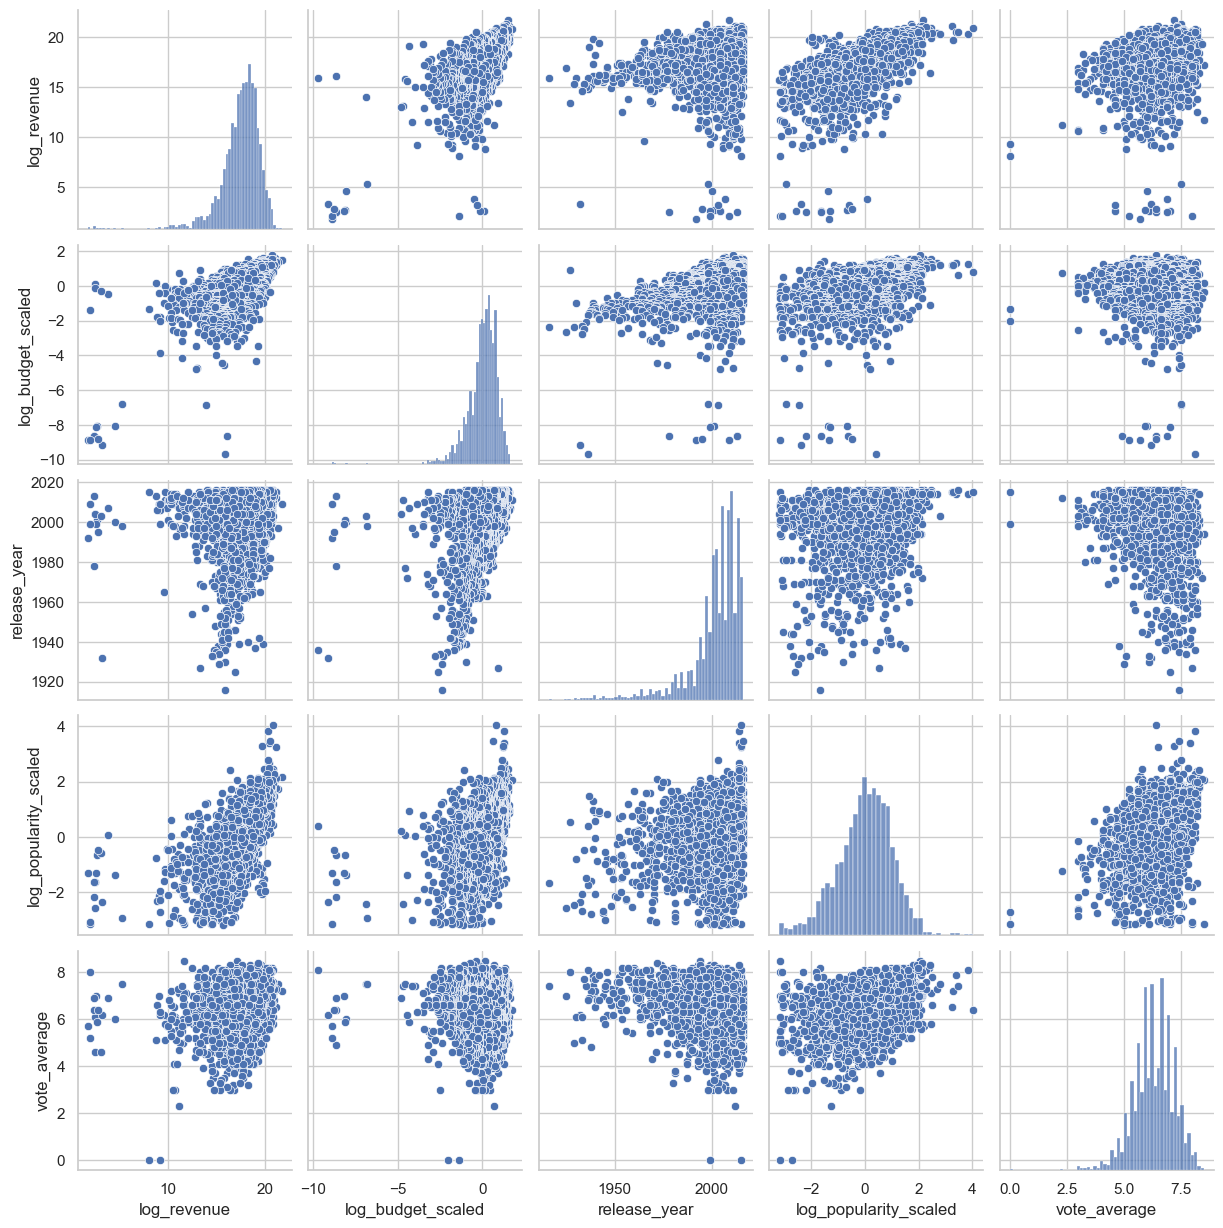

In [162]:
sns.pairplot(data.select_dtypes(include='number').loc[:, data.select_dtypes(include='number').nunique() > 2])

# Regresion multivariada

In [163]:
def forward_selection(df, target): 
    seleccionadas = []
    disponibles = df.select_dtypes(include='number').columns.tolist()

    if target not in disponibles:
        raise ValueError("La variable objetivo no está en el DataFrame o no es numérica.")

    disponibles.remove(target)
    y = df[target]
    modelo_final = None

    while disponibles:
        resultados = []

        for var in disponibles:
            X = sm.add_constant(df[seleccionadas + [var]])
            modelo = sm.OLS(y, X).fit()
            residuos = ((modelo.resid) ** 2).sum()
            r2 = modelo.rsquared
            resultados.append({'variable': var, 'R2': r2, 'residuos': residuos})

        df_resultados = pd.DataFrame(resultados)

        clear_output(wait=True)

        # Mostrar métricas actuales
        print("📌 Estado actual del modelo:")
        if seleccionadas:
            X_actual = sm.add_constant(df[seleccionadas])
            modelo_actual = sm.OLS(y, X_actual).fit()
            print(f"📈 R² actual: {modelo_actual.rsquared:.4f}")
            print(f"📉 Residuos actuales: {((modelo_actual.resid) ** 2).sum():.4f}")
        else:
            print("🔹 Aún no se han seleccionado variables.")

        print("\n📊 Variables ordenadas por R² (mayor a menor):")
        display(df_resultados.sort_values(by='R2', ascending=False).reset_index(drop=True))

        print("\n📉 Variables ordenadas por residuos (menor a mayor):")
        display(df_resultados.sort_values(by='residuos', ascending=True).reset_index(drop=True))

        print("\nVariables seleccionadas hasta ahora:", seleccionadas)
        print("Variables disponibles:", disponibles)

        seleccion = input("✏️ Ingresa la variable que deseas agregar (o 'salir' para terminar): ").strip()

        if seleccion == 'salir':
            print("\n🚪 Finalizando selección.")
            break
        elif seleccion not in disponibles:
            print("⚠️ Variable no válida. Intenta de nuevo.")
            continue

        seleccionadas.append(seleccion)
        disponibles.remove(seleccion)
        X = sm.add_constant(df[seleccionadas])
        modelo_final = sm.OLS(y, X).fit()

    clear_output(wait=True)
    print("✅ Selección final de variables:", seleccionadas)
    print(f"📈 R² final: {modelo_final.rsquared:.4f}")
    print(f"📉 Residuos finales: {((modelo_final.resid) ** 2).sum():.4f}")
    return modelo_final











def backward_selection(df, target):
    todas = df.select_dtypes(include='number').columns.tolist()
    if target not in todas:
        raise ValueError("La variable objetivo no está en el DataFrame o no es numérica.")

    seleccionadas = [v for v in todas if v != target]
    y = df[target]
    modelo_final = None

    while len(seleccionadas) > 1:
        resultados = []

        for var in seleccionadas:
            subset = [v for v in seleccionadas if v != var]
            X = sm.add_constant(df[subset])
            modelo = sm.OLS(y, X).fit()
            residuos = ((modelo.resid) ** 2).sum()
            r2 = modelo.rsquared
            resultados.append({'variable': var, 'R2_sin_variable': r2, 'residuos_sin_variable': residuos})

        df_resultados = pd.DataFrame(resultados)

        clear_output(wait=True)

        # Mostrar métricas actuales
        print("📌 Estado actual del modelo:")
        X_actual = sm.add_constant(df[seleccionadas])
        modelo_actual = sm.OLS(y, X_actual).fit()
        print(f"📈 R² actual: {modelo_actual.rsquared:.4f}")
        print(f"📉 Residuos actuales: {((modelo_actual.resid) ** 2).sum():.4f}")

        print("\n📊 Eliminación simulada: ordenadas por R² sin esa variable (mayor a menor):")
        display(df_resultados.sort_values(by='R2_sin_variable', ascending=False).reset_index(drop=True))

        print("\n📉 Eliminación simulada: ordenadas por residuos sin esa variable (menor a mayor):")
        display(df_resultados.sort_values(by='residuos_sin_variable', ascending=True).reset_index(drop=True))

        print("\nVariables seleccionadas actualmente:", seleccionadas)

        eliminar = input("✏️ Ingresa la variable que deseas eliminar (o 'salir' para terminar): ").strip()

        if eliminar == 'salir':
            print("\n🚪 Finalizando selección.")
            break
        elif eliminar not in seleccionadas:
            print("⚠️ Variable no válida. Intenta de nuevo.")
            continue

        seleccionadas.remove(eliminar)
        X = sm.add_constant(df[seleccionadas])
        modelo_final = sm.OLS(y, X).fit()

    clear_output(wait=True)
    print("✅ Selección final de variables:", seleccionadas)
    print(f"📈 R² final: {modelo_final.rsquared:.4f}")
    print(f"📉 Residuos finales: {((modelo_final.resid) ** 2).sum():.4f}")
    return modelo_final

def transformar(y, transformacion=None):

    #Aplica una transformación (log, sqrt) a una serie y actualiza su nombre.
    if not isinstance(y, pd.Series):
        raise TypeError("Se esperaba un pd.Series como entrada.")

    nombre_original = y.name or "variable"

    if transformacion == 'log':
        if (y < min(y)).any():
            raise ValueError("La transformación logarítmica requiere valores positivos.")
        y_transformada = np.log(y-min(y) + 1)  # Evita log(0) y valores negativos
        y_transformada.name = f"{nombre_original}_log"
    elif transformacion == 'sqrt':
        if (y < min(y)).any():
            raise ValueError("La raíz cuadrada requiere valores no negativos.")
        y_transformada = np.sqrt(y-min(y))  # Evita sqrt de valores negativos
        y_transformada.name = f"{nombre_original}_sqrt"
    else:
        y_transformada = y.copy()
        y_transformada.name = nombre_original

    return y_transformada

def graficar_residuos(modelo):
    """
    Genera un gráfico de residuos vs. valores predichos para un modelo OLS de statsmodels.
    
    Parámetro:
    - modelo: modelo ajustado de statsmodels (resultado de .fit())
    
    Retorna:
    - None (muestra el gráfico)
    """
    # Obtener X y Y originales del modelo
    X = modelo.model.exog
    y = modelo.model.endog

    # Obtener predicciones y residuos
    y_pred = modelo.predict(X)
    residuos = y - y_pred  # También se puede usar modelo.resid

    # Gráfico
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=y_pred, y=residuos)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Valores predichos')
    plt.ylabel('Residuos')
    plt.title('Gráfico de residuos vs. valores predichos')
    plt.show()




In [164]:
data.columns

Index(['log_revenue', 'log_budget_scaled', 'release_year', 'release_month',
       'is_business_day_release', 'genre_Drama', 'genre_Horror',
       'genre_Comedy', 'genre_Action', 'genre_Crime', 'genre_Fantasy',
       'genre_Romance', 'genre_Adventure', 'genre_Family', 'genre_Other',
       'big_studio', 'log_popularity_scaled', 'vote_average',
       'main_language_english', 'release_season'],
      dtype='object')

In [165]:
data["interaccion_1"]=data["release_year"]*data["genre_Drama"]
data["interaccion_2"]=data["release_year"]*data["genre_Action"]
data["interaccion_3"]=data["release_year"]*data["genre_Crime"]
data["interaccion_4"]=data["release_year"]*data["genre_Fantasy"]
data["interaccion_5"]=data["release_year"]*data["genre_Romance"]
data["interaccion_6"]=data["release_year"]*data["genre_Adventure"]
data["interaccion_7"]=data["release_year"]*data["genre_Family"]

data["interaccion_9"]=data["release_year"]*data["genre_Other"]


C:\Users\alexf\AppData\Local\Temp\ipykernel_20660\685882521.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["interaccion_1"]=data["release_year"]*data["genre_Drama"]
C:\Users\alexf\AppData\Local\Temp\ipykernel_20660\685882521.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["interaccion_2"]=data["release_year"]*data["genre_Action"]
C:\Users\alexf\AppData\Local\Temp\ipykernel_20660\685882521.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [166]:
data.columns

Index(['log_revenue', 'log_budget_scaled', 'release_year', 'release_month',
       'is_business_day_release', 'genre_Drama', 'genre_Horror',
       'genre_Comedy', 'genre_Action', 'genre_Crime', 'genre_Fantasy',
       'genre_Romance', 'genre_Adventure', 'genre_Family', 'genre_Other',
       'big_studio', 'log_popularity_scaled', 'vote_average',
       'main_language_english', 'release_season', 'interaccion_1',
       'interaccion_2', 'interaccion_3', 'interaccion_4', 'interaccion_5',
       'interaccion_6', 'interaccion_7', 'interaccion_9'],
      dtype='object')

## resultado

In [171]:
data['log_budget_scaled_sq'] = data['log_budget_scaled']**2
resultado4 = smf.ols('log_revenue ~log_popularity_scaled+interaccion_1+vote_average+interaccion_5+interaccion_6+log_budget_scaled+log_budget_scaled_sq+genre_Drama+big_studio+genre_Drama+genre_Horror+genre_Comedy+genre_Action+genre_Crime+genre_Fantasy+genre_Romance+genre_Adventure+genre_Family+genre_Other+C(release_season)' , data=data).fit() 
print(resultado4.summary())

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     253.0
Date:               mar, 21 abr. 2026   Prob (F-statistic):               0.00
Time:                        20:42:59   Log-Likelihood:                -5364.0
No. Observations:                3228   AIC:                         1.077e+04
Df Residuals:                    3206   BIC:                         1.091e+04
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

C:\Users\alexf\AppData\Local\Temp\ipykernel_20660\335530404.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['log_budget_scaled_sq'] = data['log_budget_scaled']**2


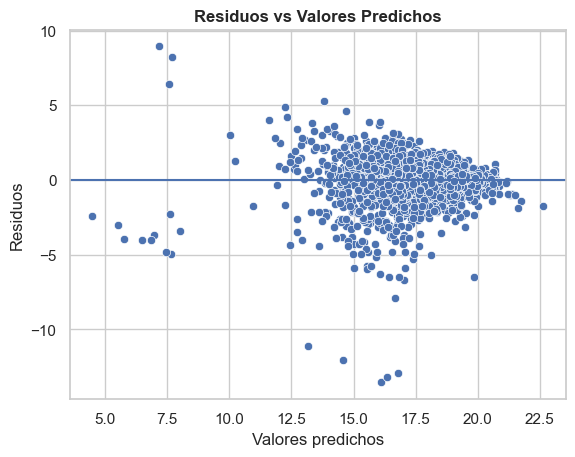

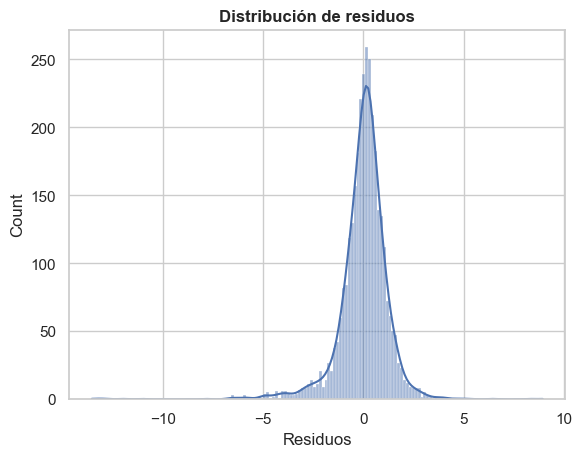

<Figure size 640x480 with 0 Axes>

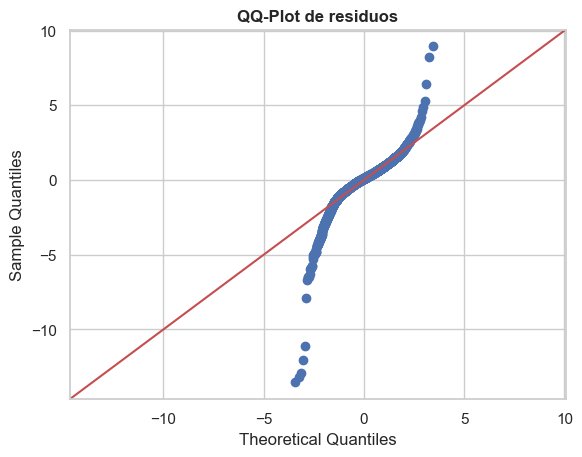

In [168]:
# Predicciones (IMPORTANTE: usar el mismo DataFrame)
y_pred = resultado4.predict(data)

# Residuos
residuos = data['log_revenue'] - y_pred

# -------------------------------
# 1. Residuos vs valores predichos
# -------------------------------
plt.figure()
sns.scatterplot(x=y_pred, y=residuos)
plt.axhline(0)
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos vs Valores Predichos")
plt.show()

# -------------------------------
# 2. Histograma de residuos
# -------------------------------
plt.figure()
sns.histplot(residuos, kde=True)
plt.xlabel("Residuos")
plt.title("Distribución de residuos")
plt.show()

# -------------------------------
# 3. QQ-plot (normalidad)
# -------------------------------
import statsmodels.api as sm

plt.figure()
sm.qqplot(residuos, line='45')
plt.title("QQ-Plot de residuos")
plt.show()

# Analisis de resultados


-vote avg tiene mayor corr con la polularidad que del revenue,por lo tanto se puede decir que en general las votaciones sirven para medir la popularidad de una pelicula que su exito en taquilla.


-el presupuesto y la popularidad estan altamente relacionados postivamente lo que nos indica que las peliculas mas populares en general suelen tener altos presupuestos

-el presupuesto tiene rendimientos decrecientes respecto a las ganancias que genera,esto nos indica que a medida que aumenta la inversion en una pelicula su ganancias aumentan,pero cada vez es mas dificil obtener ganancias proporcionales a una alta inversion,es decir el ROI de peliculas con alta inversion es menor que el de peliculas con poca inversion

-la regresion indica que la epoca que tiene mayor impacto en las ganancias de una pelicula es en verano,en donde el simple hecho de lanzarla en esta fecha y no otra puede generar un aumento del 17.43 % respecto al resto de epocas del año.

-segun la regresion los generos mas rentables son los de drama,romance y aventura y el menos rentable es el de fantasia (lo de la fantasia puede ser porque en general esas gastan mucha plata en efectos especiales y weas,en cambio las de romance son mas baratas de hacer (creo))

-que una pelicula sea pruducida por un estudio grande o no tiene un efecto muy grande sobre sus ganancias,en particulas,las peliculas producidas por estudios grande generar un 48.482% mas de ganancias que las producidas por nonames.

In [174]:
x=(np.exp(0.1607)-1)*100
print(f"{x}%")

17.43326161787653%


In [175]:
x=(np.exp(0.3953)-1)*100
print(f"{x}%")

48.48295729821592%
